# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# Dataset

In [2]:
df = pd.read_csv('loan_payment_analysis.csv')
df

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11/02/2021,13/09/2021,13/04/2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01/01/2021,14/12/2021,15/01/2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05/01/2021,12/12/2021,09/01/2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25/02/2021,12/12/2021,12/03/2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01/01/2021,14/12/2021,15/01/2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,11/07/2021,16/05/2021,16/05/2021,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,11/10/2021,16/04/2021,16/05/2021,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,11/09/2021,16/05/2021,16/05/2021,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,11/10/2021,16/05/2021,16/05/2021,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677


## Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  object 
 2   application_type       38576 non-null  object 
 3   emp_length             38576 non-null  object 
 4   emp_title              37138 non-null  object 
 5   grade                  38576 non-null  object 
 6   home_ownership         38576 non-null  object 
 7   issue_date             38576 non-null  object 
 8   last_credit_pull_date  38576 non-null  object 
 9   last_payment_date      38576 non-null  object 
 10  loan_status            38576 non-null  object 
 11  next_payment_date      38576 non-null  object 
 12  member_id              38576 non-null  int64  
 13  purpose                38576 non-null  object 
 14  sub_grade              38576 non-null  object 
 15  te

In [4]:
df.shape

(38576, 24)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,38576.0,681037.061385,211324.578218,54734.0000,513517.0000,662728.0000,8.365060e+05,1.077501e+06
member_id,38576.0,847651.506299,266810.456860,70699.0000,662978.7500,847356.5000,1.045652e+06,1.314167e+06
annual_income,38576.0,69644.540310,64293.681045,4000.0000,41500.0000,60000.0000,8.320050e+04,6.000000e+06
dti,38576.0,0.133274,0.066662,0.0000,0.0821,0.1342,1.859000e-01,2.999000e-01
installment,38576.0,326.862965,209.092000,15.6900,168.4500,283.0450,4.344425e+02,1.305190e+03
int_rate,38576.0,0.120488,0.037164,0.0542,0.0932,0.1186,1.459000e-01,2.459000e-01
loan_amount,38576.0,11296.066855,7460.746022,500.0000,5500.0000,10000.0000,1.500000e+04,3.500000e+04
total_acc,38576.0,22.132544,11.392282,2.0000,14.0000,20.0000,2.900000e+01,9.000000e+01
total_payment,38576.0,12263.348533,9051.104777,34.0000,5633.0000,10042.0000,1.665800e+04,5.856400e+04


In [6]:
df.nunique()

id                       38576
address_state               50
application_type             1
emp_length                  11
emp_title                28525
grade                        7
home_ownership               5
issue_date                  65
last_credit_pull_date      107
last_payment_date          102
loan_status                  3
next_payment_date          102
member_id                38576
purpose                     14
sub_grade                   35
term                         2
verification_status          3
annual_income             5096
dti                       2863
installment              15132
int_rate                   371
loan_amount                880
total_acc                   82
total_payment            19525
dtype: int64

### Clean The Data

In [7]:
df.isna().sum()

id                          0
address_state               0
application_type            0
emp_length                  0
emp_title                1438
grade                       0
home_ownership              0
issue_date                  0
last_credit_pull_date       0
last_payment_date           0
loan_status                 0
next_payment_date           0
member_id                   0
purpose                     0
sub_grade                   0
term                        0
verification_status         0
annual_income               0
dti                         0
installment                 0
int_rate                    0
loan_amount                 0
total_acc                   0
total_payment               0
dtype: int64

In [8]:
df.duplicated().sum()

0

#### Change All Date Columns

In [9]:
df['issue_date'] = pd.to_datetime(df['issue_date'], errors='coerce')

In [10]:
df['last_credit_pull_date'] = pd.to_datetime(df['last_credit_pull_date'], errors='coerce')

In [11]:
df['last_payment_date'] = pd.to_datetime(df['last_payment_date'], errors='coerce')

In [12]:
df['next_payment_date'] = pd.to_datetime(df['next_payment_date'], errors='coerce')

In [13]:
df.fillna(0, inplace=True)
df

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-11-02 00:00:00,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01 00:00:00,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-05-01 00:00:00,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,0,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01 00:00:00,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-11-07 00:00:00,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-11-10 00:00:00,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-11-09 00:00:00,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-11-10 00:00:00,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677


In [14]:
num_cols = ['annual_income', 'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc', 'total_payment']

cat_cols = ['address_state', 'application_type', 'emp_length', 'emp_title', 'grade', 'home_ownership', 'loan_status', 'purpose', 'sub_grade', 'term', 'verification_status']

print(len(num_cols))
print(len(cat_cols))

7
11


## Visualization

### 1. Histogram Of Num_Cols

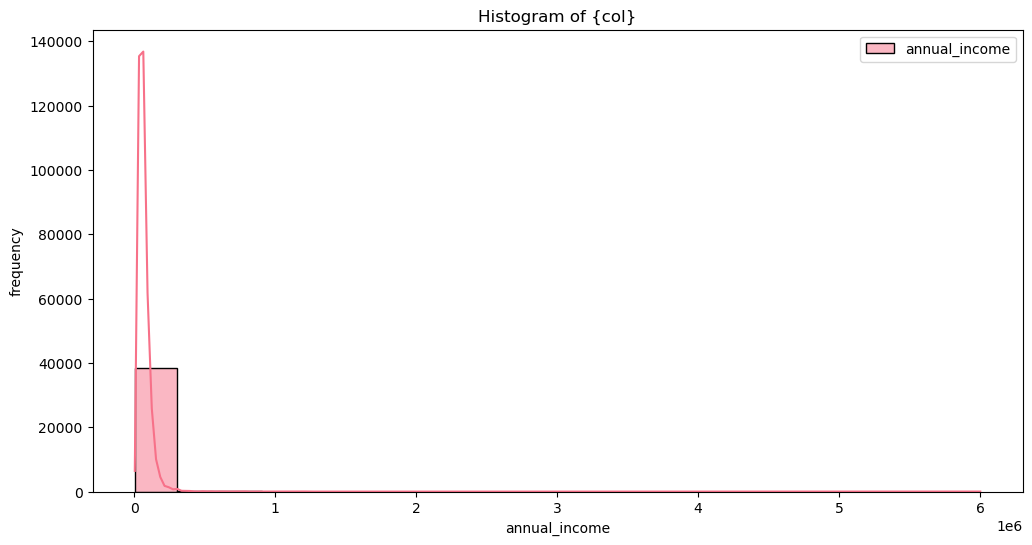

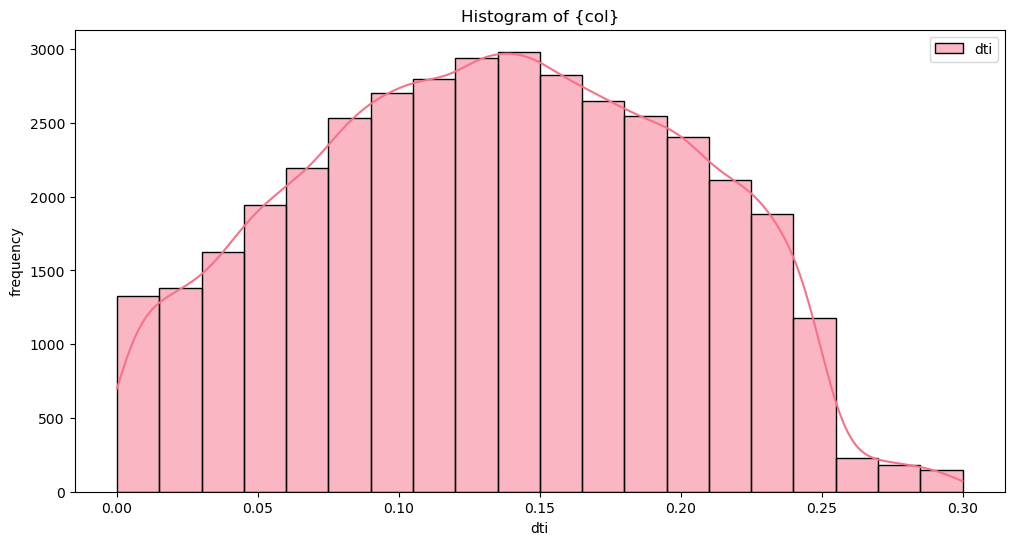

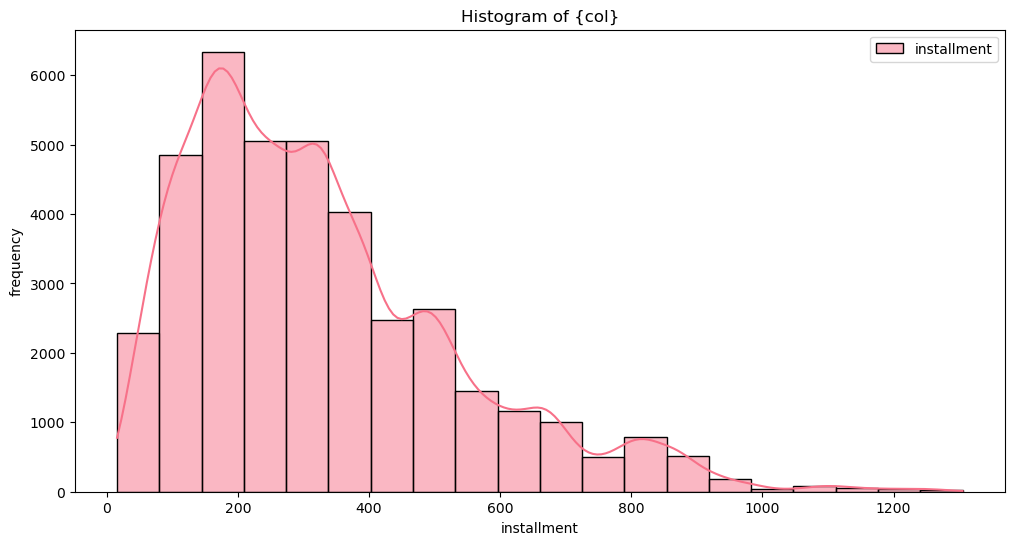

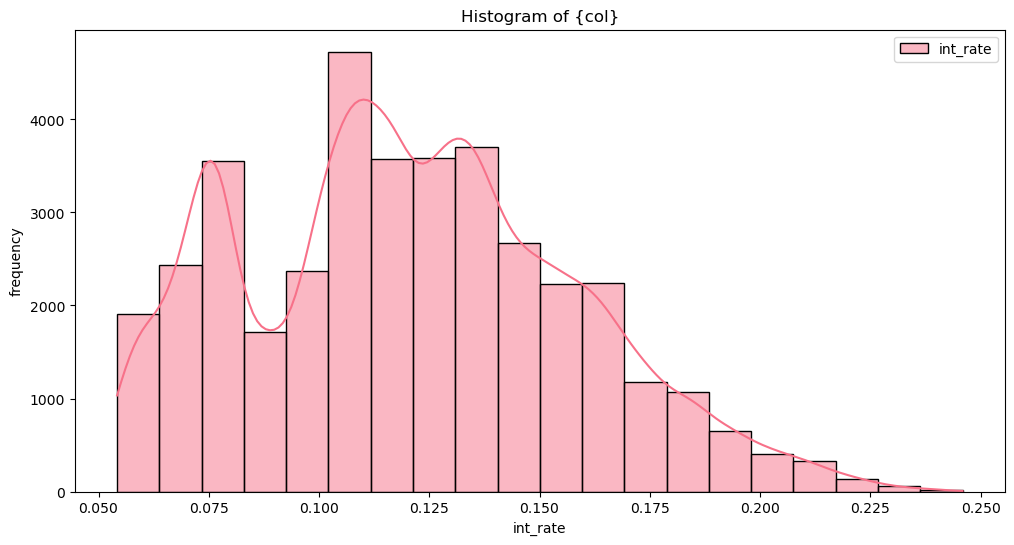

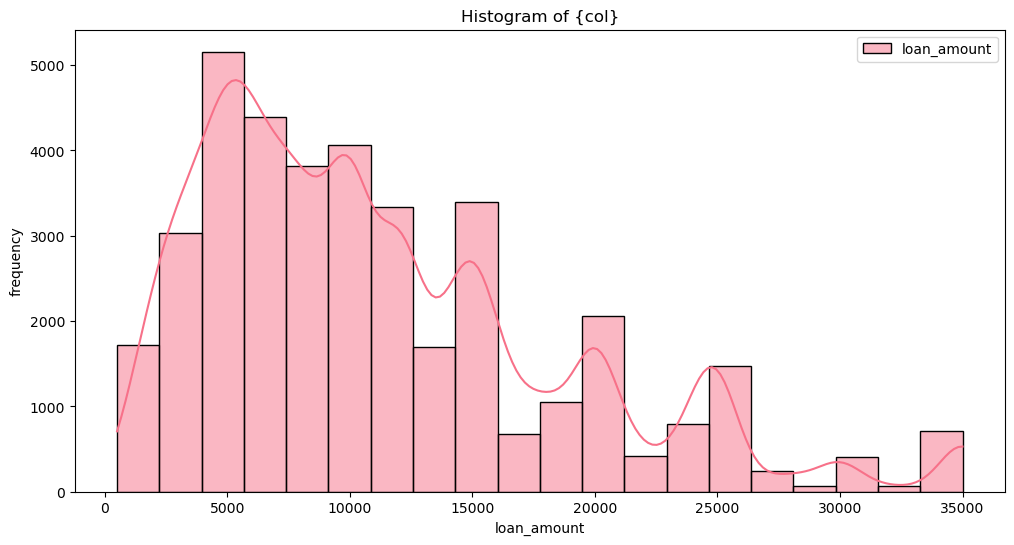

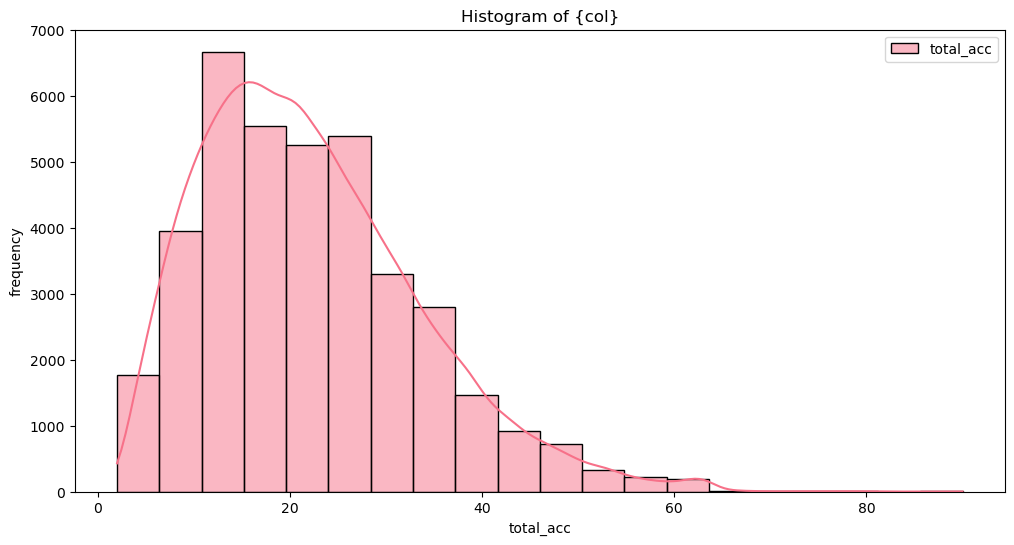

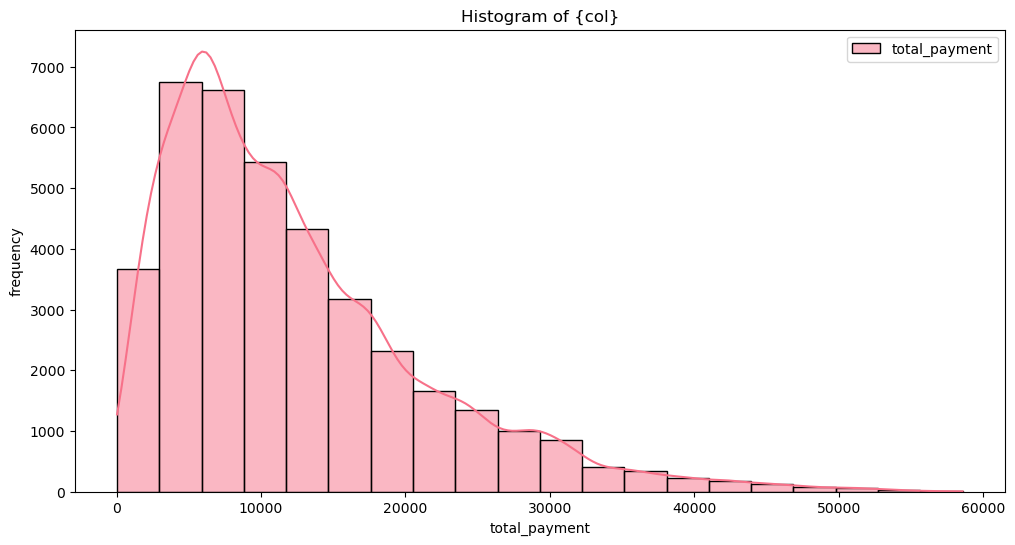

In [15]:
for col in num_cols:
    plt.figure(figsize=(12, 6))
    sns.histplot(df[[col]], kde=True, palette='husl', bins=20)
    plt.title('Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('frequency')
    plt.tight_layout
    plt.show()

### 2. Countplot Of Cat_Cols

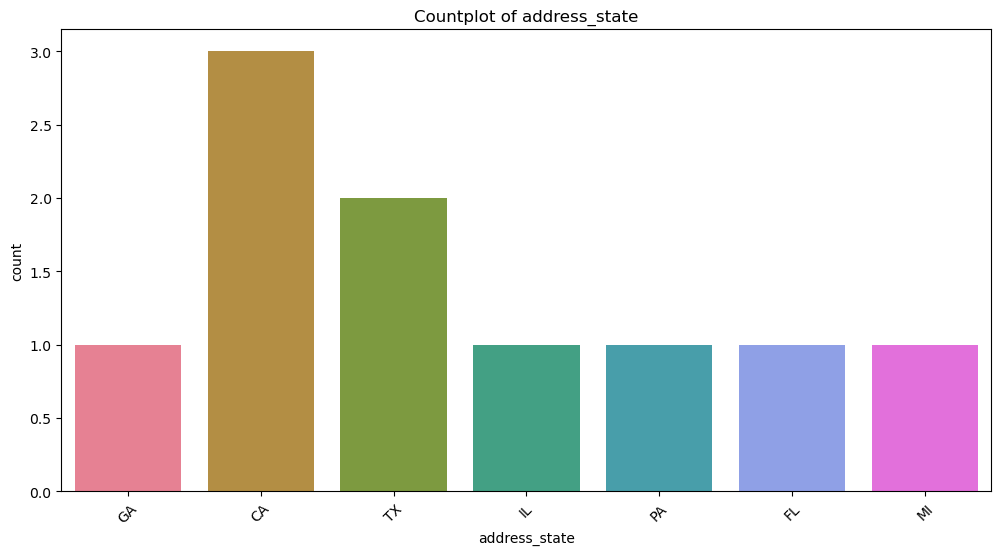

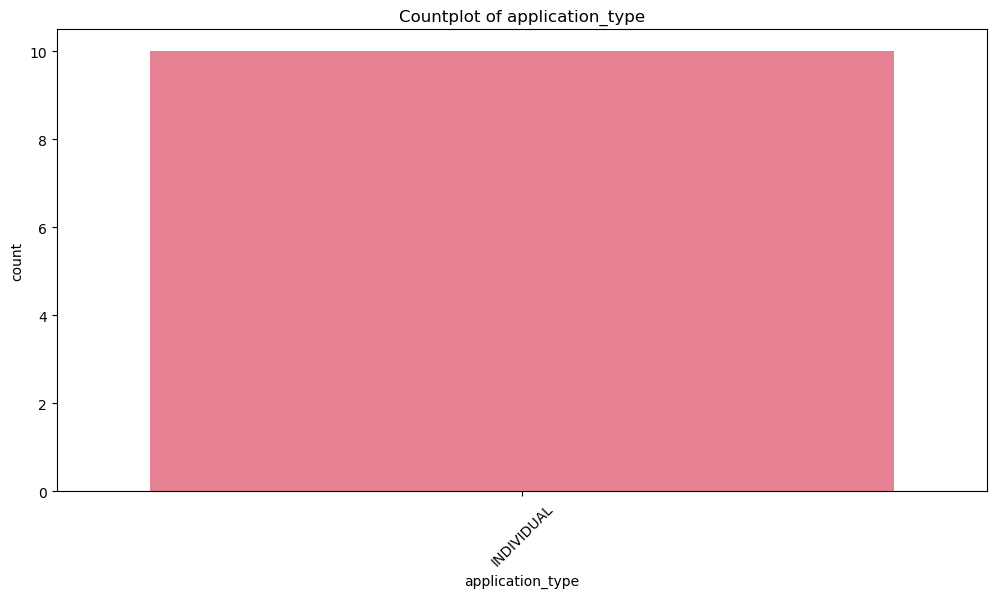

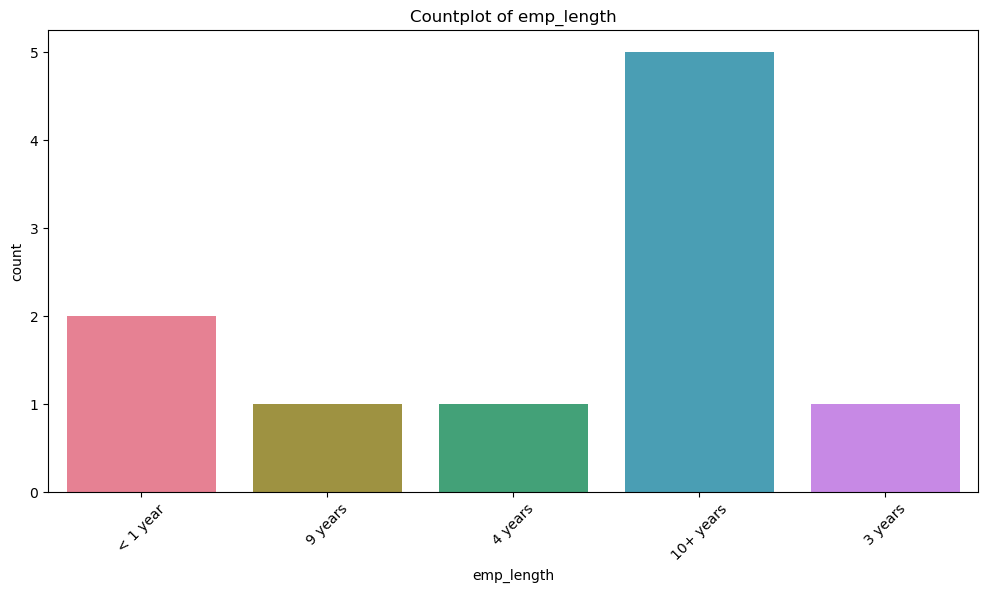

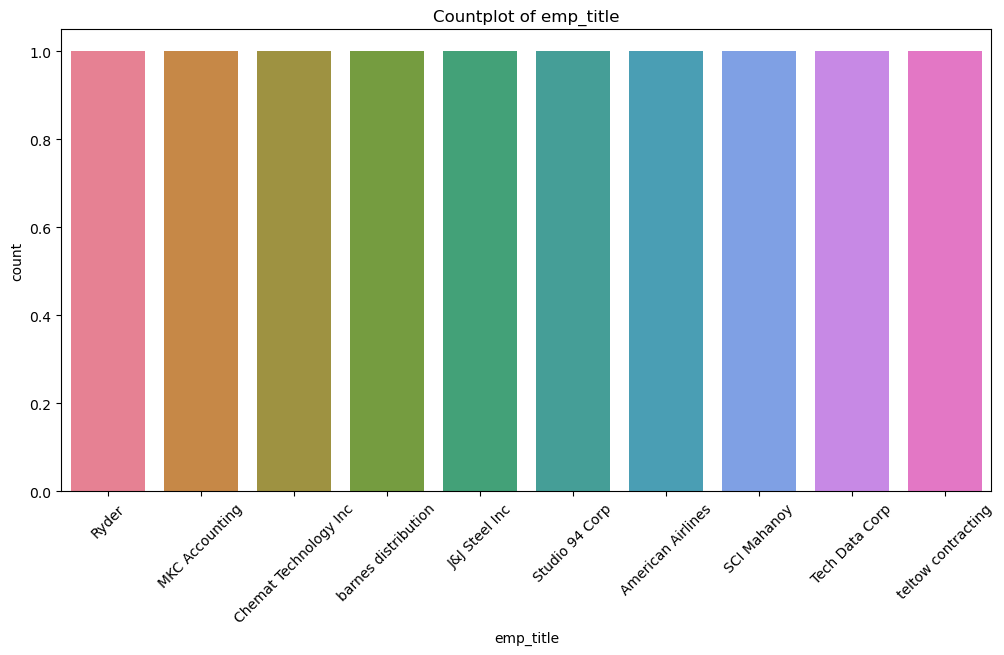

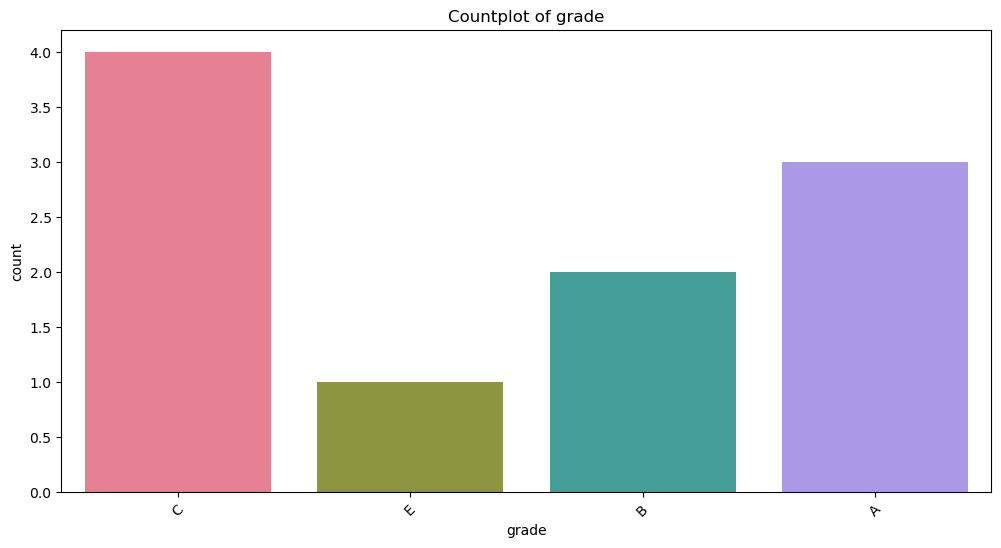

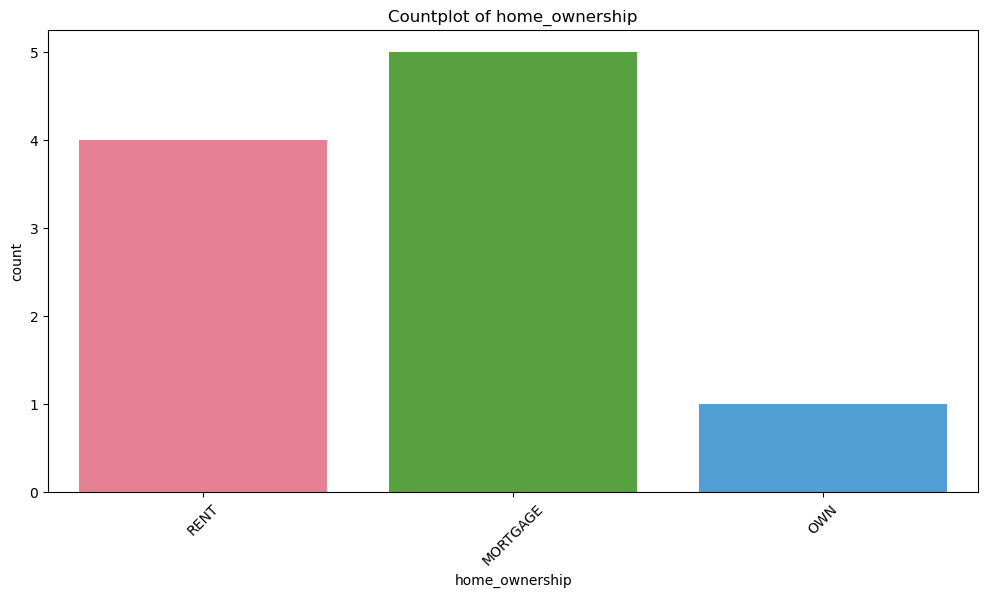

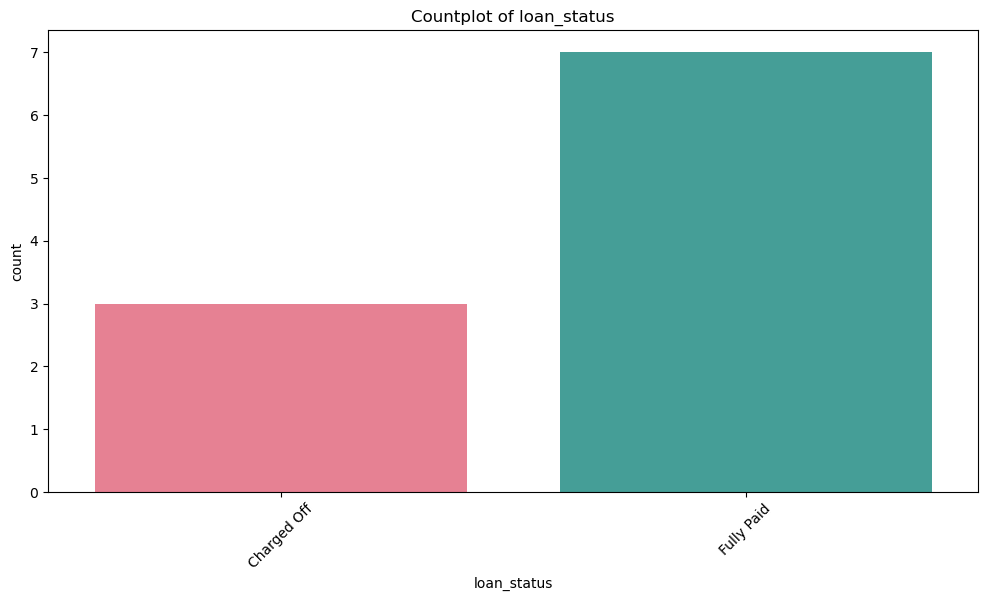

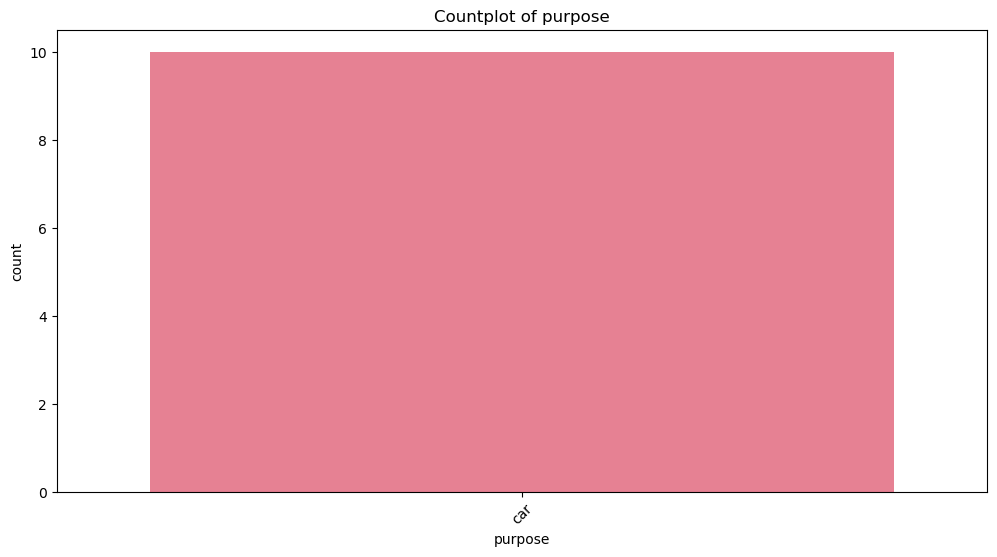

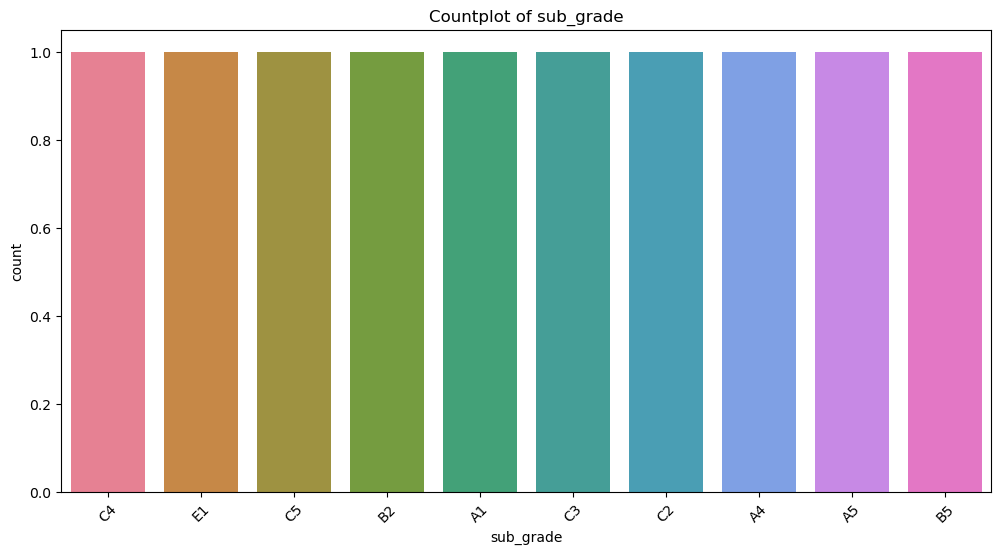

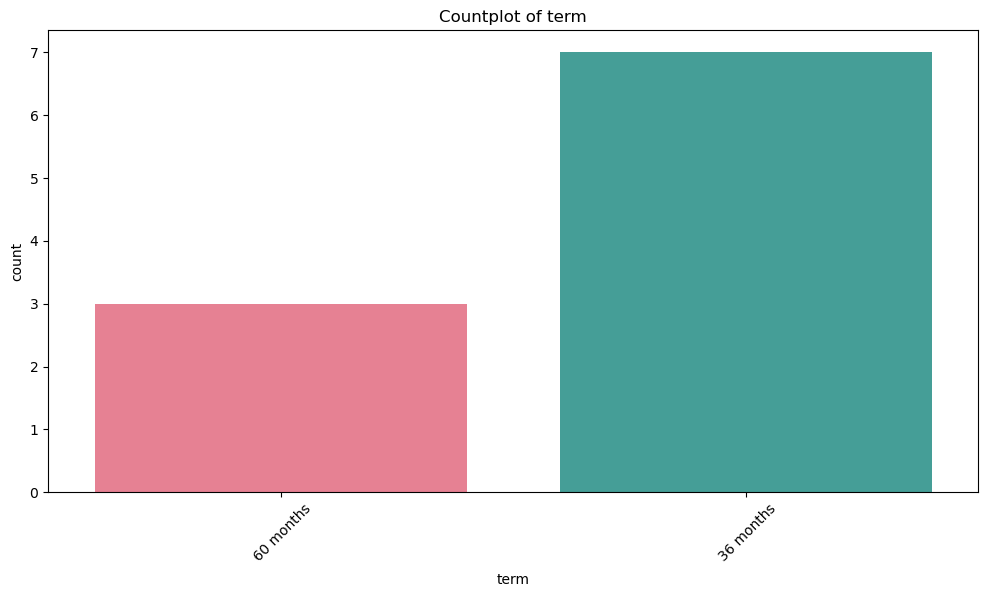

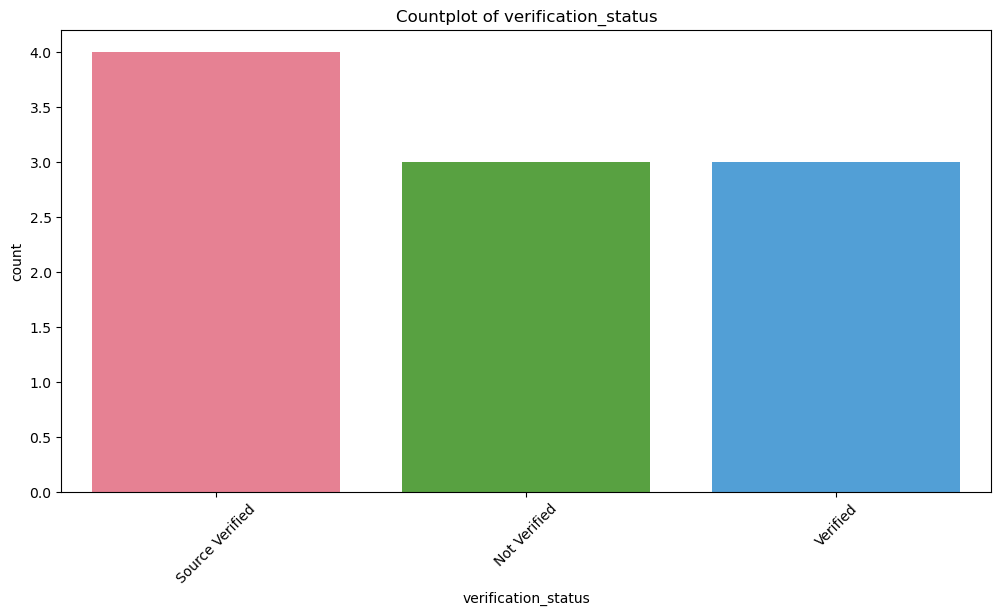

In [16]:
for col in cat_cols:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df.head(10), x=col, palette='husl')
    plt.title(f'Countplot of {col}')
    plt.xlabel(col)
    plt.ylabel('count')
    plt.xticks(rotation=45)
    plt.tight_layout
    plt.show()

### 3. Loan vs Payment by Home Ownership

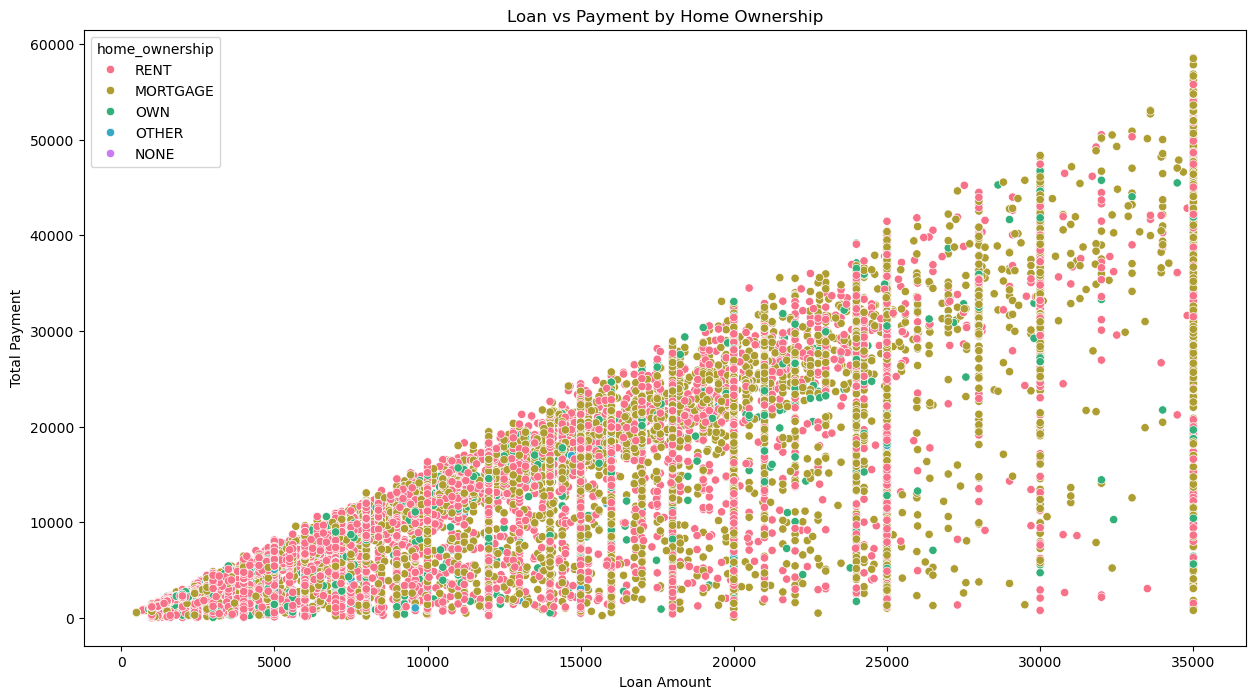

In [17]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x=df['loan_amount'], y=df['total_payment'], hue=df['home_ownership'], palette='husl')
plt.title('Loan vs Payment by Home Ownership')
plt.xlabel('Loan Amount')
plt.ylabel('Total Payment')
plt.show()

### 4. Loan Amount by Last Payment Date

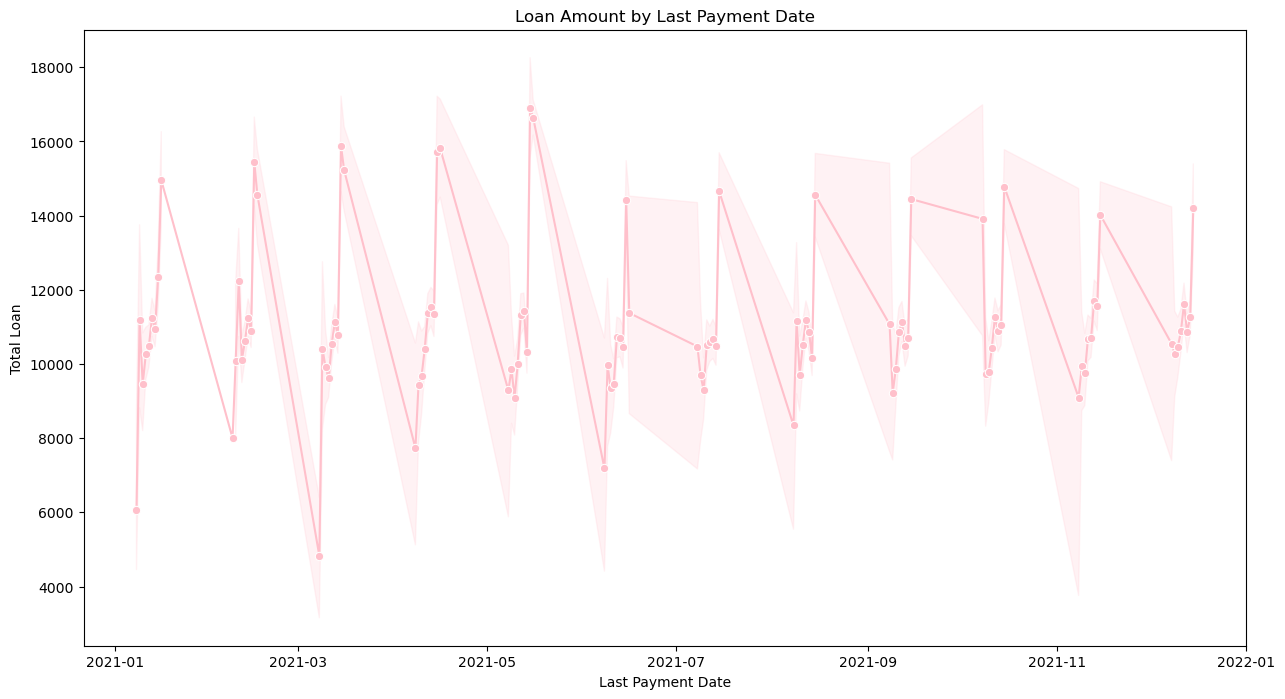

In [18]:
plt.figure(figsize=(15, 8))
sns.lineplot(x=df['last_payment_date'], y=df['loan_amount'], marker='o', color='pink')
plt.title('Loan Amount by Last Payment Date')
plt.xlabel('Last Payment Date')
plt.ylabel('Total Loan')
plt.show()

### 5. Total Payment by Home Ownership

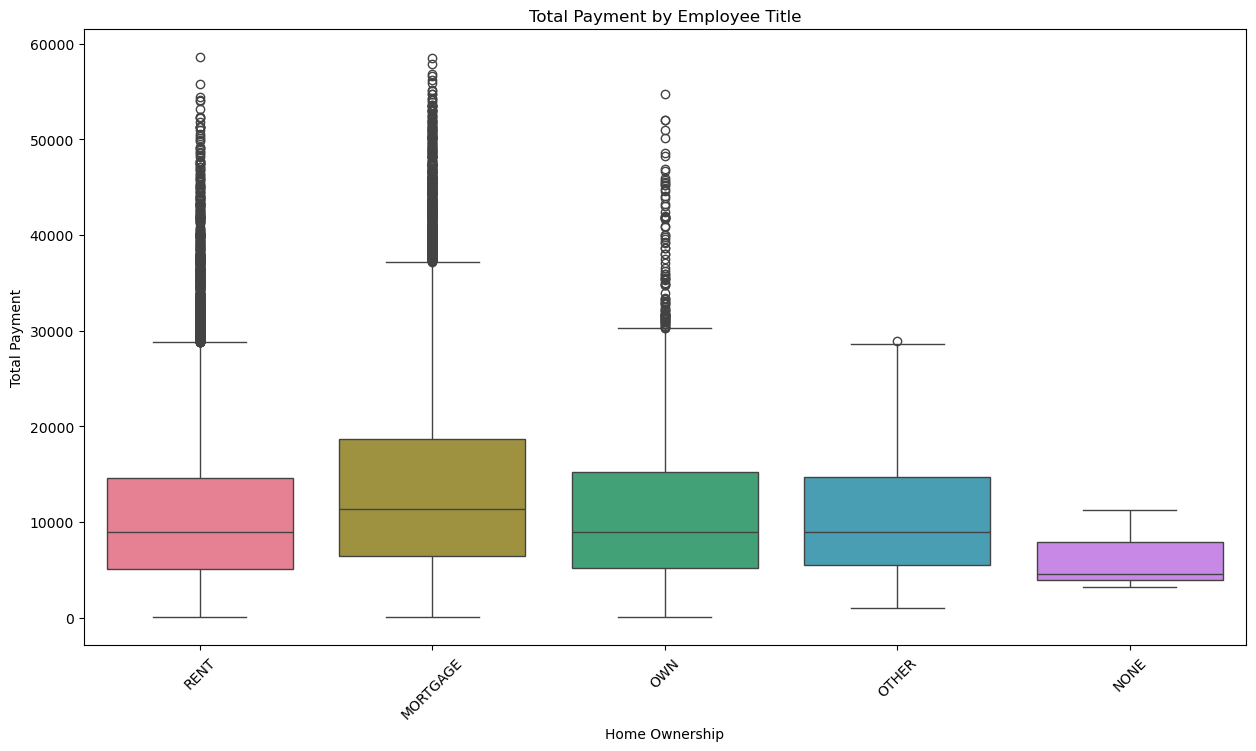

In [21]:
plt.figure(figsize=(15, 8))
sns.boxplot(x=df['home_ownership'], y=df['total_payment'], data=df, palette='husl')
plt.title('Total Payment by Employee Title')
plt.xlabel('Home Ownership')
plt.ylabel('Total Payment')
plt.xticks(rotation=45)
plt.show()

### 6. Loan Amount vs Total Payment

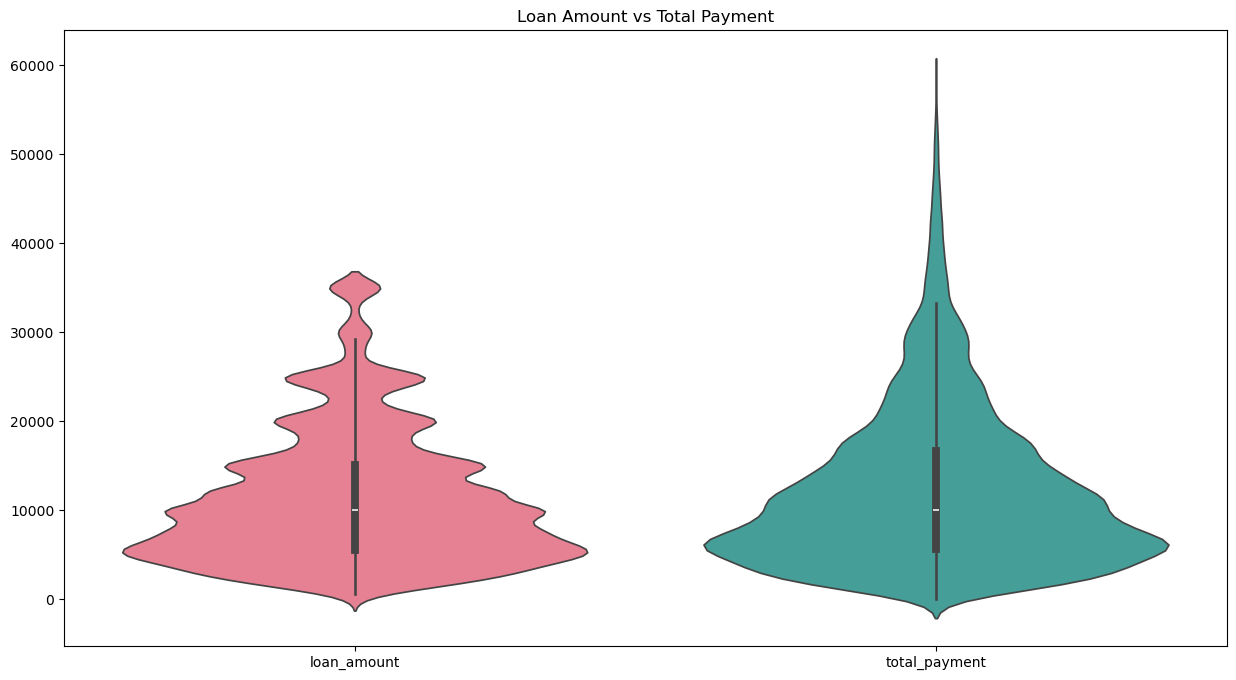

In [23]:
plt.figure(figsize=(15, 8))
sns.violinplot(data=df[['loan_amount', 'total_payment']], palette='husl')
plt.title('Loan Amount vs Total Payment')
plt.show()

### 7. Correlation Map

In [24]:
numeric_df = df.select_dtypes(include=[np.number])
numeric_df

,id,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,1314167,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,1288686,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,1304116,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,1272024,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,1302971,83000.0,0.0231,106.53,0.0603,3500,28,3835
...,...,...,...,...,...,...,...,...,...
38571,803452,992381,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,1192039,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,1089898,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,1194971,368000.0,0.0009,612.72,0.1825,24000,9,33677


In [25]:
numeric_df.dropna(subset=['id'], inplace = True)

In [26]:
numeric_df.dropna(subset=['member_id'], inplace = True)

In [27]:
correlation = numeric_df.corr()

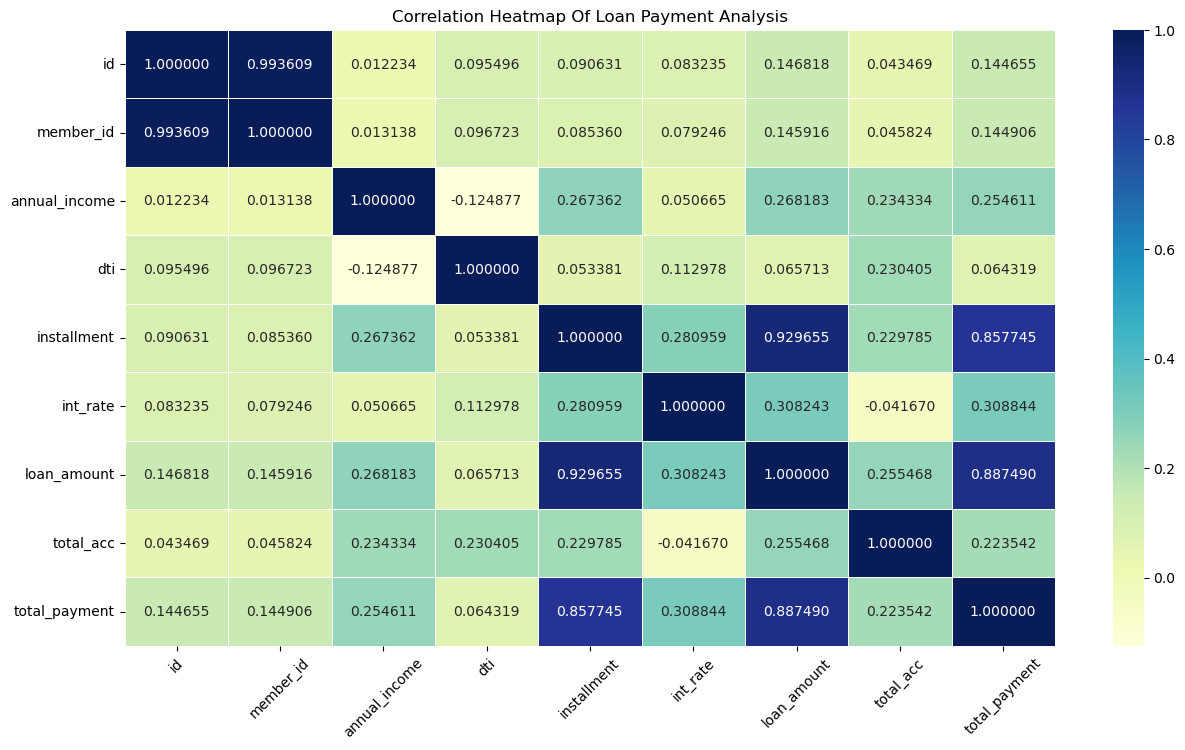

In [29]:
plt.figure(figsize=(15, 8))
sns.heatmap(correlation, annot=True, cmap='YlGnBu', fmt='2f', linewidth=0.5)
plt.title('Correlation Heatmap Of Loan Payment Analysis')
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.show()

## Predictive Modeling

In [31]:
df = df.drop(columns=['id'], errors='ignore')
df = df.drop(columns=['issue_date'], errors='ignore')
df = df.drop(columns=['last_credit_pull_date'], errors='ignore')
df = df.drop(columns=['last_payment_date'], errors='ignore')
df = df.drop(columns=['next_payment_date'], errors='ignore')
df

,address_state,application_type,emp_length,emp_title,grade,home_ownership,loan_status,member_id,purpose,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,Charged Off,1314167,car,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,Fully Paid,1288686,car,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,Charged Off,1304116,car,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,Fully Paid,1272024,car,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,Fully Paid,1302971,car,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38571,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,Current,992381,wedding,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,Current,1192039,wedding,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,Current,1089898,wedding,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,Current,1194971,wedding,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677


In [37]:
df['term'].unique()

array([' 60 months', ' 36 months'], dtype=object)

In [33]:
df['home_ownership'].unique()

array(['RENT', 'MORTGAGE', 'OWN', 'OTHER', 'NONE'], dtype=object)

In [34]:
df['loan_status'].unique()

array(['Charged Off', 'Fully Paid', 'Current'], dtype=object)

In [36]:
df['verification_status'].unique()

array(['Source Verified', 'Not Verified', 'Verified'], dtype=object)

In [38]:
val = {'verification_status': {'Not Verified': 0, 'Verified': 1, 'Source Verified': 2}, 
       'loan_status': {'Charged Off': 0, 'Current': 1, 'Fully Paid': 2},
       'home_ownership': {'NONE': 0, 'OWN': 1, 'MORTGAGE': 2, 'RENT': 3, 'OTHER': 4}
       }
df.replace(val, inplace=True)
df

,address_state,application_type,emp_length,emp_title,grade,home_ownership,loan_status,member_id,purpose,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,GA,INDIVIDUAL,< 1 year,Ryder,C,3,0,1314167,car,C4,60 months,2,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,CA,INDIVIDUAL,9 years,MKC Accounting,E,3,2,1288686,car,E1,36 months,2,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,3,0,1304116,car,C5,36 months,0,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,TX,INDIVIDUAL,< 1 year,barnes distribution,B,2,2,1272024,car,B2,60 months,2,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,2,2,1302971,car,A1,36 months,1,83000.0,0.0231,106.53,0.0603,3500,28,3835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38571,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,2,1,992381,wedding,C1,60 months,1,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,NY,INDIVIDUAL,8 years,Swat Fame,C,3,1,1192039,wedding,C1,60 months,1,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,3,1,1089898,wedding,D5,60 months,1,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,3,1,1194971,wedding,D5,60 months,1,368000.0,0.0009,612.72,0.1825,24000,9,33677


### 1. Train Test Split

In [39]:
features = ['annual_income', 'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc', 'total_payment', 'verification_status', 'home_ownership']

target = 'loan_status'

X = df[features]
y = df[target]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(30860, 9) (7716, 9)


### 2. Models

In [41]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Decison Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
}

In [42]:
best_model = None
best_accuracy = 0
best_model_name = ''

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'\n {name} Accuracy: {accuracy}')


 Logistic Regression Accuracy: 0.9230171073094868

 Decison Tree Accuracy: 0.9101866251944012

 Random Forest Accuracy: 0.9392172109901503

 Gradient Boosting Accuracy: 0.9324779678589943

 K-Nearest Neighbors Accuracy: 0.9104458268532919


#### Best Model

In [43]:
if accuracy > best_accuracy:
    best_accuracy = accuracy
    best_model = model
    best_model_name = name
    print(f'\n Best Model: {best_model_name} with Accuracy: {best_accuracy}')


 Best Model: K-Nearest Neighbors with Accuracy: 0.9104458268532919


### 3. Classification Report

In [44]:
y_pred_best = best_model.predict(X_test)
print(f'\n Classification Report: \n', classification_report(y_test, y_pred_best))


 Classification Report: 
               precision    recall  f1-score   support

           0       0.89      0.67      0.76      1064
           1       0.21      0.03      0.06       230
           2       0.92      0.98      0.95      6422

    accuracy                           0.91      7716
   macro avg       0.67      0.56      0.59      7716
weighted avg       0.89      0.91      0.90      7716



### 4. Confusion Matrix

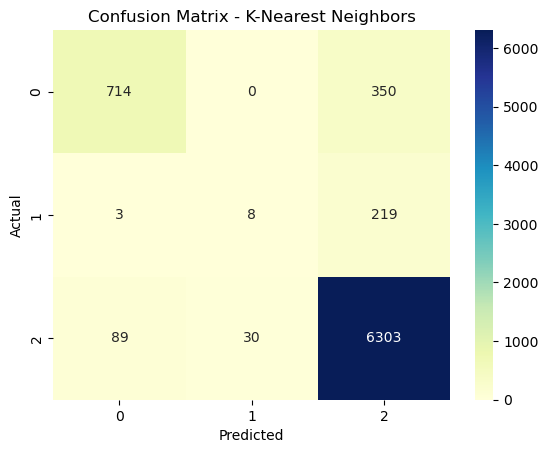

In [45]:
conf_matrix = confusion_matrix(y_test, y_pred_best)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()